In [1]:
# Import PyTorch
import torch
from torch import nn 

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
from torchmetrics import Precision, Recall, F1Score, ConfusionMatrix
# Import matplotlib for visualization
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix

# Import accuracy metric
from helper_functions import accuracy_fn

from time import time

from tqdm.auto import tqdm
# Check versions
print(torch.__version__)
print(torchvision.__version__)

2.3.0+cu118
0.18.0+cu118


## 1. Getting a dataset

In [3]:
train_data = datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # do we want the training dataset?
    download=True, # do we want to download yes/no?
    transform=torchvision.transforms.ToTensor(), # how do we want to transform the data?
    target_transform=None # how do we want to transform the labels/targets?
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
image, label = train_data[50000]

In [6]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [7]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

# 2. Visualizing our data

Text(0.5, 1.0, 'Ankle boot')

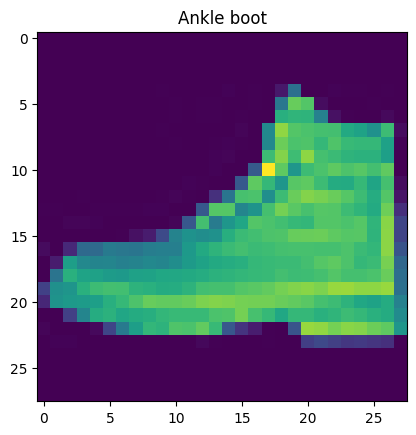

In [9]:
plt.imshow(image.squeeze())
plt.title(class_names[label])

# 3. Prepare DataLoader

In [11]:
# Setup the batch size hyperparameter
BATCH_SIZE = 64

# Turn datasets into iterables (batches)
train_dataloader = DataLoader (dataset=train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)
test_dataloader = DataLoader (dataset=test_data,
                              batch_size=BATCH_SIZE,
                              shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x1847465bf10>,
 <torch.utils.data.dataloader.DataLoader at 0x1847465b640>)

In [12]:
# Let's check out what what we've created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")
print(train_dataloader.batch_size)

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x000001847465BF10>, <torch.utils.data.dataloader.DataLoader object at 0x000001847465B640>)
Length of train_dataloader: 938 batches of 64...
Length of test_dataloader: 157 batches of 64...
64


# 4. Model: Building a Convolutional Neural Network (CNN)

In [14]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device,
               num_classes: int = 10,       
               task: str = "multiclass"):  
    
    """Performs a training step with model trying to learn on data_loader."""
    
    precision_metric = Precision(task=task, num_classes=num_classes).to(device)
    recall_metric = Recall(task=task, num_classes=num_classes).to(device)
    f1_metric = F1Score(task=task, num_classes=num_classes).to(device)
    
    train_loss, train_acc = 0, 0

    model.train()

    for batch, (X, y) in enumerate(data_loader):
        
        X, y = X.to(device), y.to(device)

        y_pred_logits = model(X)
        
        y_pred_labels = y_pred_logits.argmax(dim=1)
        
        loss = loss_fn(y_pred_logits, y)
        train_loss += loss.item()
        
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred_labels)
        
        precision_metric.update(y_pred_labels, y)
        recall_metric.update(y_pred_labels, y)
        f1_metric.update(y_pred_labels, y)
        
        optimizer.zero_grad()
        
        loss.backward()
        
        optimizer.step()
  
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    
    total_precision = precision_metric.compute().item()
    total_recall = recall_metric.compute().item()
    total_f1 = f1_metric.to(device).compute().item()
    
    precision_metric.reset()
    recall_metric.reset()
    f1_metric.reset()

    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")
    print(f"Train Precision: {total_precision:.4f} | Train Recall: {total_recall:.4f} | Train F1-Score: {total_f1:.4f}")
    
    return train_loss, train_acc, total_precision, total_recall, total_f1

In [15]:
def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader, 
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device,
              num_classes: int = 10, 
              task: str = "multiclass"): 
    
    """Performs a testing loop step on model going over data_loader."""
    
    precision_metric = Precision(task=task, num_classes=num_classes).to(device)
    recall_metric = Recall(task=task, num_classes=num_classes).to(device)
    f1_metric = F1Score(task=task, num_classes=num_classes).to(device)
    
    test_loss, test_acc = 0, 0
  
    model.eval()

    with torch.inference_mode():
        for X, y in data_loader:
            
            X, y = X.to(device), y.to(device)

            test_pred_logits = model(X)
            
            test_pred_labels = test_pred_logits.argmax(dim=1)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            
            test_acc += accuracy_fn(y_true=y,
                                    y_pred=test_pred_labels)
            
            precision_metric.update(test_pred_labels, y)
            recall_metric.update(test_pred_labels, y)
            f1_metric.update(test_pred_labels, y)

        test_loss /= len(data_loader)
        test_acc /= len(data_loader)
        
        total_precision = precision_metric.compute().item()
        total_recall = recall_metric.compute().item()
        total_f1 = f1_metric.compute().item()
        
        precision_metric.reset()
        recall_metric.reset()
        f1_metric.reset()
        
        print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")
        print(f"Test Precision: {total_precision:.4f} | Test Recall: {total_recall:.4f} | Test F1-Score: {total_f1:.4f}\n")
        
        return test_loss, test_acc, total_precision, total_recall, total_f1

In [16]:
torch.manual_seed(42)

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module, 
               accuracy_fn,
               device: torch.device,
               num_classes: int = 10,      
               task: str = "multiclass"): 
    
    """Returns a dictionary containing the results of the model predicting on data_loader."""
    
    precision_metric = Precision(task=task, num_classes=num_classes).to(device)
    recall_metric = Recall(task=task, num_classes=num_classes).to(device)
    f1_metric = F1Score(task=task, num_classes=num_classes).to(device)
    
    loss, acc = 0, 0
    model.eval()
    
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            
            X, y = X.to(device), y.to(device)
            
            y_pred_logits = model(X)
            y_pred_labels = y_pred_logits.argmax(dim=1)

            loss += loss_fn(y_pred_logits, y).item() # استخدام .item() لمنع استهلاك الذاكرة
            acc += accuracy_fn(y_true=y, y_pred=y_pred_labels)
            
            precision_metric.update(y_pred_labels, y)
            recall_metric.update(y_pred_labels, y)
            f1_metric.update(y_pred_labels, y)

        loss /= len(data_loader)
        acc /= len(data_loader)
        
        total_precision = precision_metric.compute().item()
        total_recall = recall_metric.compute().item()
        total_f1 = f1_metric.compute().item()
        
        precision_metric.reset()
        recall_metric.reset()
        f1_metric.reset()

    return {
        "model_name": model.__class__.__name__, 
        "model_loss": loss,
        "model_acc": acc,
        "model_precision": total_precision,
        "model_recall": total_recall,
        "model_f1_score": total_f1
    } 

In [17]:
class VGGAdvanced(nn.Module):
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int):
        super().__init__()
        
        # Conv + Pool
        self.block_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        self.block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units*2, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(hidden_units*2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        
        # Classification
        self.classifier = nn.Sequential(
            nn.Flatten(),
            #nn.Linear(in_features=hidden_units*2 * 7 * 7, out_features=128),
            #nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(in_features=hidden_units*2 * 7 * 7, out_features=output_shape)
        )

    def forward(self, x):
        x = self.block_1(x)
        x = self.block_2(x)
        x = self.classifier(x)
        return x

In [18]:
model = VGGAdvanced(input_shape=1, hidden_units=32, output_shape=10)

# 5. Setup a loss function and optimizer for model

In [20]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model.parameters(), 
                             lr=0.1)

# 6. etup device-agnostic code

In [22]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

# 7. Training and testing `model` using our training and test functions

In [24]:
torch.manual_seed(42)

model.to(device)

start_time = time()

# Train and test model 
epochs = 5
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n---------")
    train_step(data_loader=train_dataloader, 
        model=model, 
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
        device=device
    )
    test_step(data_loader=test_dataloader,
        model=model,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device=device
    )

end_time = time()

total_train_time = end_time - start_time
print(f"Total training time: {total_train_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.58482 | Train acc: 82.63%
Train Precision: 0.8262 | Train Recall: 0.8262 | Train F1-Score: 0.8262
Test loss: 0.35111 | Test acc: 87.80%
Test Precision: 0.8777 | Test Recall: 0.8777 | Test F1-Score: 0.8777

Epoch: 1
---------
Train loss: 0.31434 | Train acc: 88.52%
Train Precision: 0.8853 | Train Recall: 0.8853 | Train F1-Score: 0.8853
Test loss: 0.31114 | Test acc: 88.96%
Test Precision: 0.8894 | Test Recall: 0.8894 | Test F1-Score: 0.8894

Epoch: 2
---------
Train loss: 0.27354 | Train acc: 90.20%
Train Precision: 0.9021 | Train Recall: 0.9021 | Train F1-Score: 0.9021
Test loss: 0.30088 | Test acc: 88.88%
Test Precision: 0.8889 | Test Recall: 0.8889 | Test F1-Score: 0.8889

Epoch: 3
---------
Train loss: 0.24787 | Train acc: 91.04%
Train Precision: 0.9104 | Train Recall: 0.9104 | Train F1-Score: 0.9104
Test loss: 0.25779 | Test acc: 90.53%
Test Precision: 0.9048 | Test Recall: 0.9048 | Test F1-Score: 0.9048

Epoch: 4
---------
Train loss: 0.23191 | Tra

# 8. Get model results 

In [26]:
model_results = eval_model(
    model=model,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_results

  0%|          | 0/157 [00:00<?, ?it/s]

{'model_name': 'VGGAdvanced',
 'model_loss': 0.28493773230132025,
 'model_acc': 89.72929936305732,
 'model_precision': 0.8974000215530396,
 'model_recall': 0.8974000215530396,
 'model_f1_score': 0.8974000215530396}

## 9. Make and evaluate random predictions with best model

In [29]:
def make_predictions(model: torch.nn.Module, data: list, device: torch.device = device):
    pred_probs = []
    model.eval()
    with torch.inference_mode():
        for sample in data:
          
            sample = torch.unsqueeze(sample, dim=0).to(device) 

            pred_logit = model(sample)

            pred_prob = torch.softmax(pred_logit.squeeze(), dim=0) 
          
            pred_probs.append(pred_prob.cpu())
            
    return torch.stack(pred_probs)

In [30]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=12):
    test_samples.append(sample)
    test_labels.append(label)
    
print(f"Test sample image shape: {test_samples[0].shape}\nTest sample label: {test_labels[0]} ({class_names[test_labels[0]]})")

Test sample image shape: torch.Size([1, 28, 28])
Test sample label: 5 (Sandal)


Text(0.5, 1.0, 'Sandal')

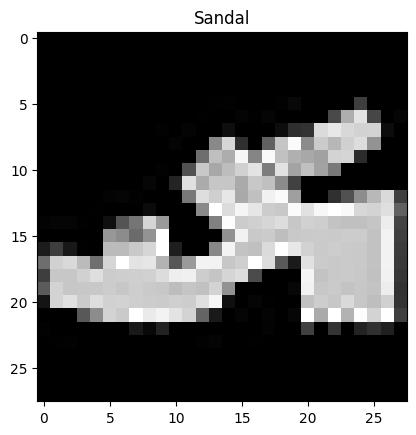

In [31]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [32]:
pred_probs= make_predictions(model=model, 
                             data=test_samples)

In [33]:
pred_classes = pred_probs.argmax(dim=1)
pred_classes

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1, 9, 7, 2])

In [34]:
test_labels, pred_classes

([5, 1, 7, 4, 3, 0, 4, 7, 1, 9, 7, 2],
 tensor([5, 1, 7, 4, 3, 0, 4, 7, 1, 9, 7, 2]))

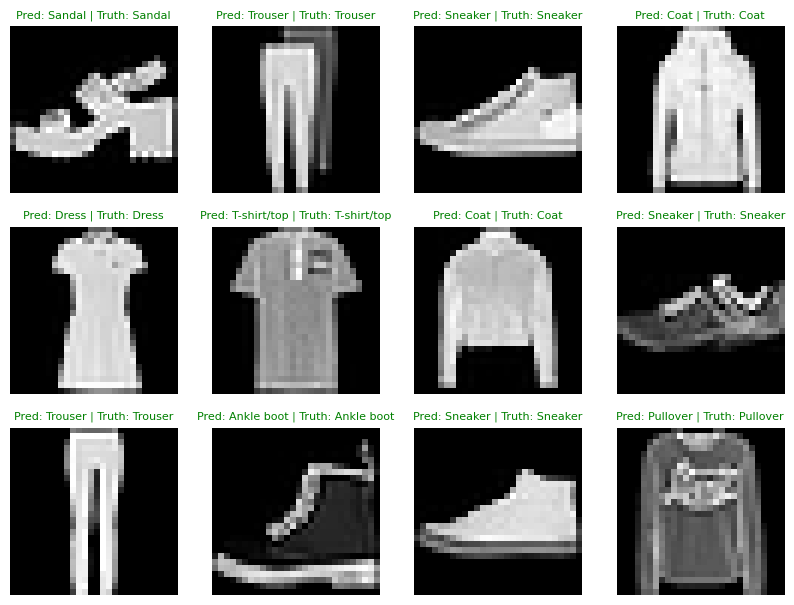

In [35]:
plt.figure(figsize=(10, 10))
nrows = 4
ncols = 4
for i, sample in enumerate(test_samples):

  plt.subplot(nrows, ncols, i+1)

  plt.imshow(sample.squeeze(), cmap="gray")

  pred_label = class_names[pred_classes[i]]

  truth_label = class_names[test_labels[i]] 

  title_text = f"Pred: {pred_label} | Truth: {truth_label}"
  
  if pred_label == truth_label:
      plt.title(title_text, fontsize=8, c="g") 
  else:
      plt.title(title_text, fontsize=8, c="r")
  plt.axis(False);

# 10. Making a confusion matrix for further prediction evaluation 

In [37]:
# 1. Make predictions with trained model
y_preds = []
model.eval()
with torch.inference_mode():
    
    for i, (X, y) in enumerate(tqdm(test_dataloader, desc="Making predictions...")):   
      
        X, y = X.to(device), y.to(device)
   
        y_logit = model(X)

        y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
        
        y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor

Making predictions...:   0%|          | 0/157 [00:00<?, ?it/s]

tensor([9, 2, 1,  ..., 8, 1, 4])

In [38]:
len(y_pred_tensor)

10000

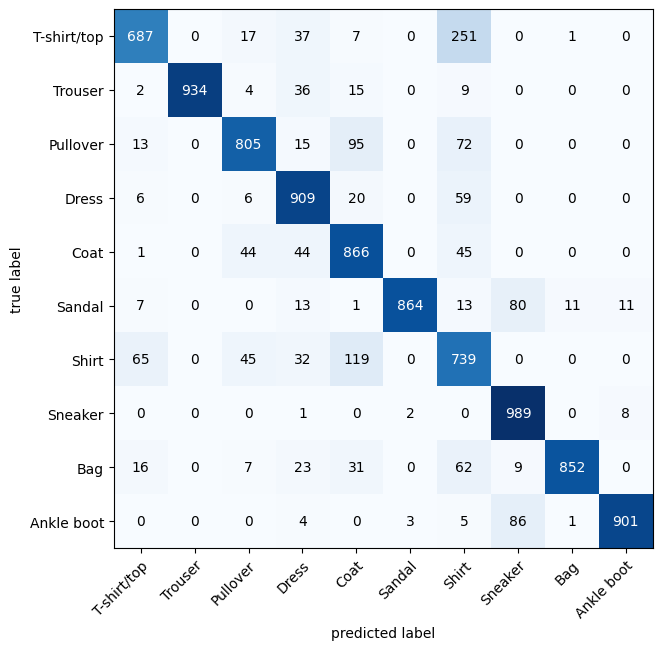

In [39]:
from mlxtend.plotting import plot_confusion_matrix

confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))

confmat_tensor = confmat(preds=y_pred_tensor, 
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(), 
    class_names=class_names,
    figsize=(10, 7)
)

# 11. Save and load best performing model

In [41]:
print(f"Saving model to: models/VGGAdvanced.pth")
torch.save(obj=model.state_dict(),
           f="models/VGGAdvanced.pth")

Saving model to: models/VGGAdvanced.pth
